In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('classic')
import numpy as np
import calendar
from datetime import datetime, timedelta
import argparse
from scipy.stats.mstats import mquantiles

sns.set()

import matplotlib.dates as mdates

import locale

locale.setlocale(locale.LC_TIME, "es_ES")

'es_ES'

In [2]:
print(f"Old Directory: {os.getcwd()}")
os.chdir(r'../')
print(f"New Directory: {os.getcwd()}")

Old Directory: d:\GitHub\Sala_Situacion_Dinagua\Status_Outlook_Bulletin\notebook
New Directory: d:\GitHub\Sala_Situacion_Dinagua\Status_Outlook_Bulletin


In [3]:
def quantile_position(x, p, alphap=0.4, betap=0.4):
    # For Weibull use alphap = 0.0 and betap = 0.0. For Cunnane use alphap = 0.4 and betap = 0.4
    return mquantiles(x.dropna(), p, alphap=alphap, betap=betap)[0]

In [4]:
# Quantile Function Definitions
def q1(x):
    return quantile_position(x, 0.28,alphap=0.4, betap=0.4)
def q2(x):   
    return quantile_position(x, 0.50,alphap=0.4, betap=0.4)
def q3(x):   
    return quantile_position(x, 0.72,alphap=0.4, betap=0.4)
def q5(x):   
    return quantile_position(x, 0.05,alphap=0.4, betap=0.4)
def q95(x):  
    return quantile_position(x, 0.95,alphap=0.4, betap=0.4)
def q87(x):  
    return quantile_position(x, 0.87,alphap=0.4, betap=0.4)
def q13(x):  
    return quantile_position(x, 0.13,alphap=0.4, betap=0.4)
def q10(x):  
    return quantile_position(x, 0.10,alphap=0.4, betap=0.4)
def q25(x):  
    return quantile_position(x, 0.25,alphap=0.4, betap=0.4)
def q75(x):  
    return quantile_position(x, 0.75,alphap=0.4, betap=0.4)
def q90(x):  
    return quantile_position(x, 0.90,alphap=0.4, betap=0.4)

In [5]:
'''
# Define arguments 
parser = argparse.ArgumentParser(
                    prog='calculate_hydrological_status',
                    description='Plot ESP outlook from codcuenca n2',
                    epilog='Jose Valles, DINAGUA, 26082024')

# 
parser.add_argument('codcuenca_n2', help='provide the input time series frequency (daily or monthly)')
parser.add_argument('end_date', help='end date for the discharge plot in format YYYY-MM-DD')    
parser.add_argument('leadtime', help='lead time for the forecast in months')    

args = parser.parse_args()

'''
args = argparse.Namespace(
    codcuenca_n2='61',
    end_date='2026-06-01',
    leadtime='1'
)


In [6]:
# Calculate start date as one year before the provided end date
end_date = datetime.strptime(args.end_date, '%Y-%m-%d')
start_date = end_date - timedelta(days=365)  # Subtracting 365 days for a year difference
# Format dates as strings
start_date_str = start_date.strftime('%Y-%m-%d')
end_date_str = end_date.strftime('%Y-%m-%d')


In [7]:
# Define the basin level 2 code 
codcuenca_n2 = int(args.codcuenca_n2)

In [8]:
basin_level3 = pd.read_csv(f'./waterbalance/balance_hidrico_regional/output_modelo/cuenca_nivel3.csv',usecols=lambda col: col.startswith(str(codcuenca_n2)))
basin_level2 = pd.read_csv(f'./waterbalance/balance_hidrico_regional/output_modelo/cuenca_nivel2.csv',usecols=lambda col: col.startswith(str(codcuenca_n2)))


In [9]:
# Insert the folder path 
folder_path = './waterbalance/balance_hidrico_regional/output_modelo/esp/'
# get a list of all CSV file in the folder
file_list = [file for file in os.listdir(folder_path) if file.endswith('.csv')]
# Initialize an empty list to store dataframes
df_list = []

# Iterate over the list of files and read each one into a dataframe
for file in file_list:
    # Importar los datos 
    file_path = os.path.join(folder_path,file)
    year_analogue = os.path.splitext(os.path.basename(file_path))[0][-4:]
    df = pd.read_csv(file_path,usecols=lambda col: col.startswith((str(codcuenca_n2),'-1')))
    df = df.rename(columns={'-1': 'year','-1.1':'month'})
    df['date'] = pd.to_datetime(dict(year=df['year'],month=df['month'],day=1))
    df = df.set_index('date')
    df['days_in_month'] = df.index.days_in_month
    # Convert into discharge units
    df_selected = df.drop(['year','month','days_in_month'],axis=1)
    discharge = pd.DataFrame(df_selected.values*1000*basin_level3.values,columns=df_selected.columns)
    discharge['days_in_month'] = df['days_in_month'].values
    discharge = discharge.loc[:, discharge.columns != 'days_in_month'].divide(discharge["days_in_month"]*24*3600, axis="index")
    discharge['date'] = df.index.values
    discharge = discharge.set_index('date')
    discharge['year'] = df['year'].values
    discharge['month'] = df['month'].values
    # Aggregate discharge
    aggregate_discharge = pd.DataFrame()
    aggregate_discharge['year'] = discharge['year']
    aggregate_discharge['month'] = discharge['month']
    discharge = discharge.drop(['year','month'],axis=1)
    aggregate_discharge['discharge'] = discharge.sum(axis=1)
    aggregate_discharge['year_analogue'] = year_analogue
    # extract only the forecast
    forecast_rows = aggregate_discharge.iloc[-7:]
    df_list.append(forecast_rows)
    aggregate_discharge = aggregate_discharge.iloc[:-6,:]

concat_df = pd.concat(df_list)

In [10]:
concat_df = concat_df.reset_index()

In [11]:
DISCHARGE_SELECTION = (aggregate_discharge[(aggregate_discharge['year'] >= 1981) & (aggregate_discharge['year'] <= 2010)]).drop(columns='year_analogue')


In [12]:
percentiles = DISCHARGE_SELECTION.groupby(DISCHARGE_SELECTION.month).quantile([0.10,0.25,0.75,0.90])
percentiles = percentiles.reset_index()
percentiles = percentiles.drop(columns=['year'])
percentiles.rename(columns={'level_1':'percentile','discharge':'discharge_percentile'}, inplace=True)

In [13]:
max_values = DISCHARGE_SELECTION.groupby(DISCHARGE_SELECTION.month).max()
max_values = max_values.drop(columns=['year'])
min_values = DISCHARGE_SELECTION.groupby(DISCHARGE_SELECTION.month).min()
min_values = min_values.drop(columns=['year'])

In [14]:
min_values.query('month==3')['discharge'].item()

0.0023923905092592596

In [15]:
percentiles['date'] = pd.to_datetime(percentiles['month'],format='%m',errors='coerce')
percentiles['date'] = percentiles['date'].dt.to_period('M').dt.to_timestamp()

In [16]:
discharge_plot = aggregate_discharge.loc[start_date_str:end_date_str]
discharge_plot = discharge_plot.reset_index()

In [17]:
# create empty columns in the dataframe
discharge_plot['10th_percentile'] = np.nan
discharge_plot['25th_percentile'] = np.nan
discharge_plot['75th_percentile'] = np.nan
discharge_plot['90th_percentile'] = np.nan

for i in range(len(discharge_plot)):
    # Extract the current month 
    m = discharge_plot.month[i]
    discharge_plot.loc[discharge_plot.eval('month==@m'),'minimum']  = percentiles.query('month==@m & percentile==0.10')['discharge_percentile'].item()
    discharge_plot.loc[discharge_plot.eval('month==@m'),'10th_percentile']  = percentiles.query('month==@m & percentile==0.10')['discharge_percentile'].item()
    discharge_plot.loc[discharge_plot.eval('month==@m'),'25th_percentile']  = percentiles.query('month==@m & percentile==0.25')['discharge_percentile'].item()
    discharge_plot.loc[discharge_plot.eval('month==@m'),'75th_percentile']  = percentiles.query('month==@m & percentile==0.75')['discharge_percentile'].item()
    discharge_plot.loc[discharge_plot.eval('month==@m'),'90th_percentile']  = percentiles.query('month==@m & percentile==0.90')['discharge_percentile'].item()


In [18]:
df_stats = pd.DataFrame(index=pd.date_range(start=discharge_plot['date'].iloc[0], end=concat_df['date'].iloc[-1], freq='MS',inclusive='both'))
df_stats['month'] = df_stats.index.month
df_stats = df_stats.rename_axis('date')

In [19]:
# create empty columns in the dataframe
df_stats['10th_percentile'] = np.nan
df_stats['25th_percentile'] = np.nan
df_stats['75th_percentile'] = np.nan
df_stats['90th_percentile'] = np.nan

for i in range(len(df_stats)):
    # Extract the current month 
    m = df_stats.month[i]
    df_stats.loc[df_stats.eval('month==@m'),'10th_percentile']  = percentiles.query('month==@m & percentile==0.10')['discharge_percentile'].item()
    df_stats.loc[df_stats.eval('month==@m'),'25th_percentile']  = percentiles.query('month==@m & percentile==0.25')['discharge_percentile'].item()
    df_stats.loc[df_stats.eval('month==@m'),'75th_percentile']  = percentiles.query('month==@m & percentile==0.75')['discharge_percentile'].item()
    df_stats.loc[df_stats.eval('month==@m'),'90th_percentile']  = percentiles.query('month==@m & percentile==0.90')['discharge_percentile'].item()

df_stats = df_stats.reset_index()

In [20]:
concat_df['group'] = concat_df.index // 7

In [21]:
discharge_max_plot = max(concat_df['discharge'].max(),discharge_plot['discharge'].max())
discharge_max_plot = round(discharge_max_plot/100)*100

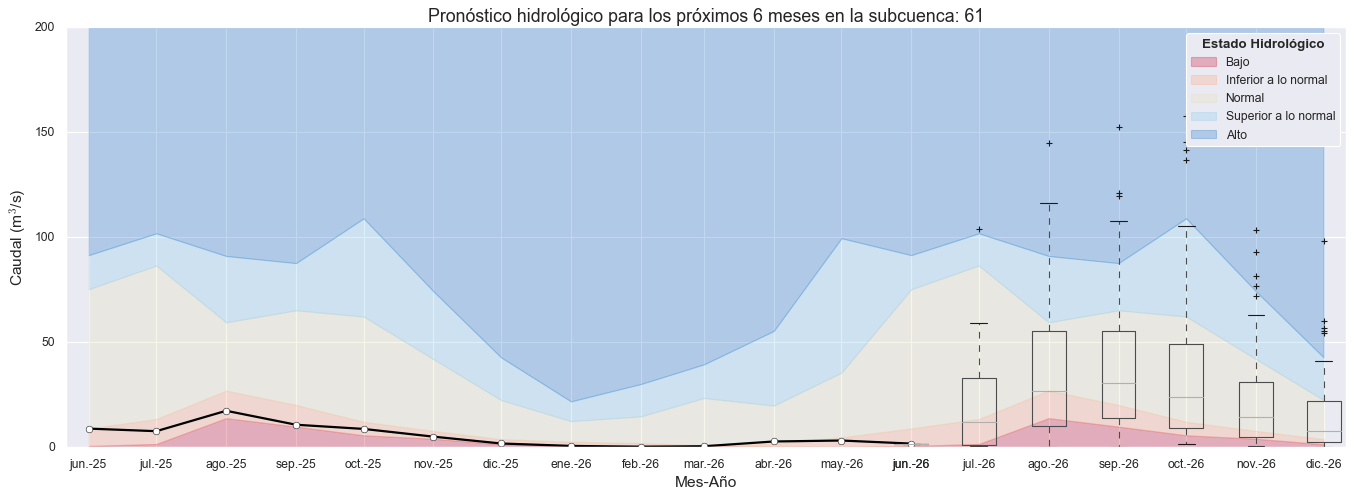

In [22]:
## Get the earliest date in BOTH plots combined
begin=pd.concat([discharge_plot.date, pd.Series(concat_df.date.unique())]).min()

## Add columns linepos and boxpos to the dataframes to show offset from earliest date
discharge_plot['linepos']=(discharge_plot['date']-begin).dt.days
concat_df['boxpos']=(concat_df['date']-begin).dt.days
df_stats['linepos'] = (df_stats['date']-begin).dt.days

## Plot plots - note I am using boxpos and linepos, not dates for x-axis
ax=concat_df[['discharge', 'boxpos']].boxplot(by='boxpos', widths=15, positions=concat_df.boxpos.unique(),figsize=(20,7))
ax.plot(discharge_plot['linepos'], discharge_plot['discharge'], label='_nolegend_',color = 'black',linewidth=2,marker='o', mfc='white', mec='k')
ax.fill_between(df_stats['linepos'], 0, df_stats['10th_percentile'], color='#CD233F', alpha=0.3,label="Bajo")
ax.fill_between(df_stats['linepos'], df_stats['10th_percentile'], df_stats['25th_percentile'], color='#FFA885', alpha=0.3,label="Inferior a lo normal")
ax.fill_between(df_stats['linepos'], df_stats['25th_percentile'], df_stats['75th_percentile'], color='#E7E2BC', alpha=0.3,label="Normal")
ax.fill_between(df_stats['linepos'], df_stats['75th_percentile'], df_stats['90th_percentile'], color='#8ECEEE', alpha=0.3,label="Superior a lo normal")
ax.fill_between(df_stats['linepos'], df_stats['90th_percentile'], discharge_max_plot,color='#2C7DCD', alpha=0.3,label="Alto")

## Set x-lim to include both line and boxes
ax.set_xlim([ min(concat_df.boxpos.min(), discharge_plot.linepos.min())-10, max(concat_df.boxpos.max(), discharge_plot.linepos.max()) + 10 ] )

## To change the x-axis ticks, get the list of all x-entries and sort
locs=(list(concat_df.boxpos.unique())+list(discharge_plot.linepos.unique()))
locs.sort()
ax.set_xticks(locs)
ax.set_ylim(0,discharge_max_plot)
# ax.set_ylim(0,500)

## To add labels get unique dates, sort them, convert to format you like and plot
ax.set_xticklabels(pd.concat([discharge_plot.date, pd.Series(concat_df.date.unique())]).sort_values().reset_index(drop=True).dt.strftime('%b-%y'), rotation=90 )

## Set x and y labels
ax.set_xlabel('Mes-Año',fontsize=14);
ax.set_title(f'Pronóstico hidrológico para los próximos 6 meses en la subcuenca: {codcuenca_n2}',fontsize=16)
ax.set_ylabel('Caudal (m$^3$/s)',fontsize=14);
ax.legend(loc='best',title='Estado Hidrológico',fancybox=True, title_fontproperties={'weight':'bold'})
plt.xticks(rotation=0);
plt.suptitle('');
# plt.savefig('./waterbalance/output_png/01_boxplot_outlook.png', dpi=300, bbox_inches='tight')
# plt.close()
plt.show()

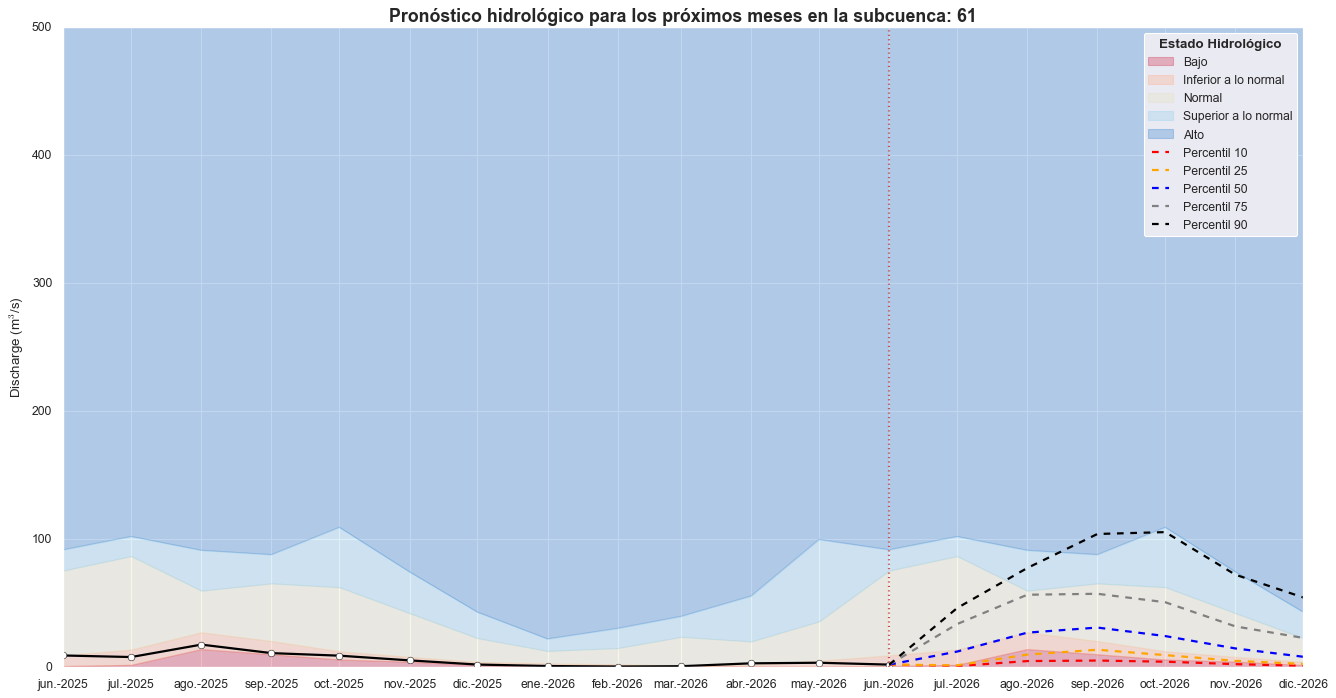

In [23]:
# stats_fcst = concat_df.groupby('month')['discharge'].agg([np.min, q10, q25, q2, q75, q90,np.max, np.std,np.mean])
stats_fcst = concat_df.groupby('date')['discharge'].agg([np.min, q10, q25, q2, q75, q90,np.max, np.std,np.mean])
d = pd.DataFrame(index=pd.date_range(start=concat_df['date'].iloc[-7], end=concat_df['date'].iloc[-1], freq='MS',inclusive='both'))
stats_fcst['date'] = d.index
# %%
fig4, ax4 = plt.subplots(figsize=(20, 10))
ax4.plot(discharge_plot['date'],discharge_plot['discharge'],color = 'black',linewidth=2,marker='o', mfc='white', mec='k', label='_nolegend_');



# ax2.set_xticklabels(pd.concat([discharge_plot.date, pd.Series(concat_df.date.unique())]).sort_values().reset_index(drop=True).dt.strftime('%b/%Y'), rotation=90 )
ax4.fill_between(df_stats['date'], 0, df_stats['10th_percentile'], color='#CD233F', alpha=0.3,label="Bajo")
ax4.fill_between(df_stats['date'], df_stats['10th_percentile'], df_stats['25th_percentile'], color='#FFA885', alpha=0.3,label="Inferior a lo normal")
ax4.fill_between(df_stats['date'], df_stats['25th_percentile'], df_stats['75th_percentile'], color='#E7E2BC', alpha=0.3,label="Normal")
ax4.fill_between(df_stats['date'], df_stats['75th_percentile'], df_stats['90th_percentile'], color='#8ECEEE', alpha=0.3,label="Superior a lo normal")
ax4.fill_between(df_stats['date'], df_stats['90th_percentile'], 600,color='#2C7DCD', alpha=0.3,label="Alto")

ax4.plot(stats_fcst['date'],stats_fcst['q10'],color = 'red',linestyle = '--',linewidth=2, mec='k', label='Percentil 10')
ax4.plot(stats_fcst['date'],stats_fcst['q25'],color = 'orange',linestyle = '--',linewidth=2, mec='k', label='Percentil 25')
ax4.plot(stats_fcst['date'],stats_fcst['q2'],color = 'blue',linestyle = '--',linewidth=2, mec='k', label='Percentil 50')
ax4.plot(stats_fcst['date'],stats_fcst['q75'],color = 'gray',linestyle = '--',linewidth=2, mec='k', label='Percentil 75')
ax4.plot(stats_fcst['date'],stats_fcst['q90'],color = 'black',linestyle = '--',linewidth=2, mec='k', label='Percentil 90')

ax4.set_title(f'Pronóstico hidrológico para los próximos meses en la subcuenca: {codcuenca_n2}',fontweight='bold',fontsize=16)
# ax4.set_ylim(0,discharge_max_plot)
ax4.set_ylim(0,500)
ax4.legend(loc='best',title='Estado Hidrológico',fancybox=True, title_fontproperties={'weight':'bold'})
ax4.set_ylabel('Discharge (m$^3$/s)');

ax4.axvline(x = stats_fcst['date'].iloc[0], color = 'r',label = 'now', linestyle=':', linewidth=2, mfc='white', mec='k');

ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=1))   #to get a tick every 1 month
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))   #optional formatting 
plt.xticks(rotation=0);
# plt.savefig('./waterbalance/output_png/02_percentile_outlook.png', dpi=300, bbox_inches='tight')
# plt.close()
plt.show()

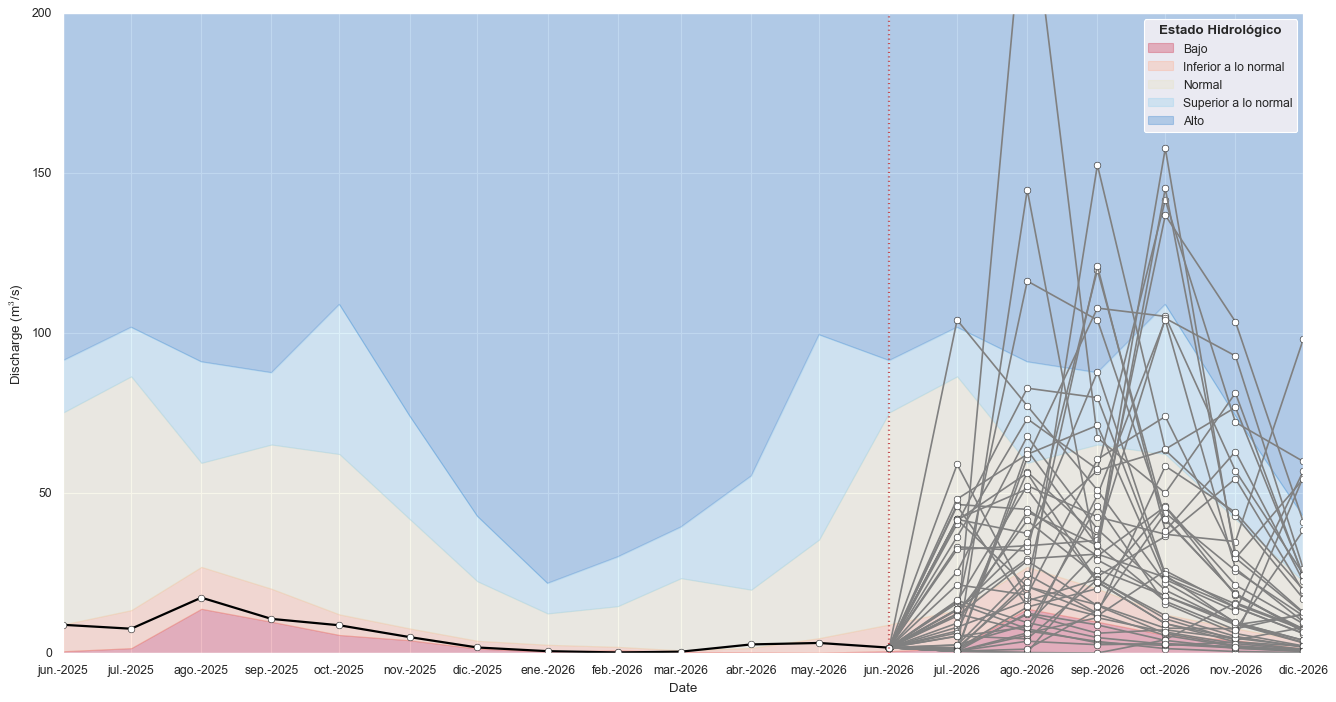

In [24]:
fig2, ax2 = plt.subplots(figsize=(20, 10))
ax2.plot(discharge_plot['date'],discharge_plot['discharge'],color = 'black',linewidth=2,marker='o', mfc='white', mec='k', label='_nolegend_');
for group,data in concat_df.groupby('group'):
    ax2.plot(data['date'],data['discharge'],color = 'gray',linewidth=1.5,marker='o', mfc='white', mec='k', label='_nolegend_')
ax2.set_xlabel('Date');
## To add labels get unique dates, sort them, convert to format you like and plot
# ax2.set_xticklabels(pd.concat([discharge_plot.date, pd.Series(concat_df.date.unique())]).sort_values().reset_index(drop=True).dt.strftime('%b/%Y'), rotation=90 )
ax2.fill_between(df_stats['date'], 0, df_stats['10th_percentile'], color='#CD233F', alpha=0.3,label="Bajo")
ax2.fill_between(df_stats['date'], df_stats['10th_percentile'], df_stats['25th_percentile'], color='#FFA885', alpha=0.3,label="Inferior a lo normal")
ax2.fill_between(df_stats['date'], df_stats['25th_percentile'], df_stats['75th_percentile'], color='#E7E2BC', alpha=0.3,label="Normal")
ax2.fill_between(df_stats['date'], df_stats['75th_percentile'], df_stats['90th_percentile'], color='#8ECEEE', alpha=0.3,label="Superior a lo normal")
ax2.fill_between(df_stats['date'], df_stats['90th_percentile'], 600,color='#2C7DCD', alpha=0.3,label="Alto")
ax2.set_ylim(0,discharge_max_plot)
# ax2.set_ylim(0,500)
ax2.legend(loc='best',title='Estado Hidrológico',fancybox=True, title_fontproperties={'weight':'bold'})
ax2.set_ylabel('Discharge (m$^3$/s)');

ax2.axvline(x = stats_fcst['date'].iloc[0], color = 'r',label = 'now', linestyle=':', linewidth=2, mfc='white', mec='k');

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))   #to get a tick every 1 month
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))   #optional formatting 
plt.xticks(rotation=0);
# plt.savefig('./waterbalance/output_png/03_spaguetti_outlook.png', dpi=300, bbox_inches='tight')
# plt.close()
plt.show()

In [25]:
selected_years = [1982, 2008, 1993]
concat_df['year_analogue'] = concat_df['year_analogue'].astype(int)
years_to_select = [int(year) for year in selected_years]

# Crear el subset
filtered_concat_df = concat_df[concat_df['year_analogue'].isin(years_to_select)]

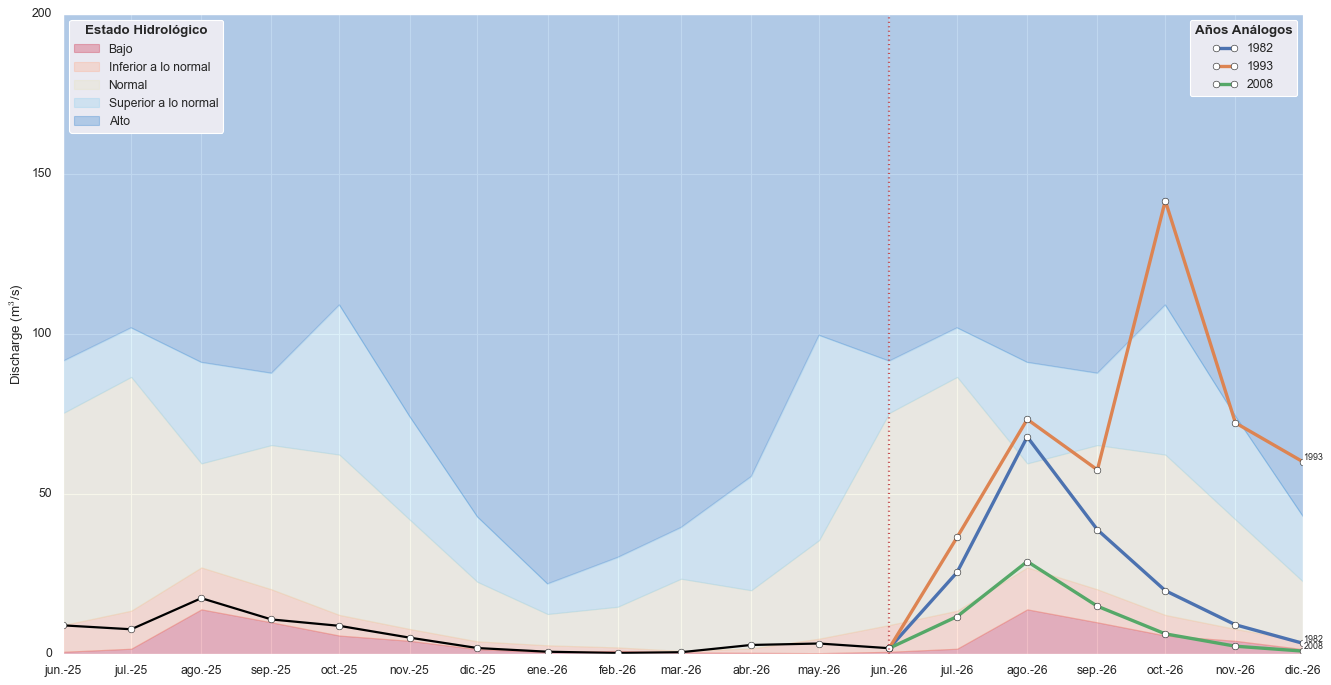

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig5, ax5 = plt.subplots(figsize=(20, 10))
analogue_handles = []

# Gráfico de la serie principal
ax5.plot(discharge_plot['date'], discharge_plot['discharge'], color='black', linewidth=2, marker='o', mfc='white', mec='k', label='_nolegend_')

# Gráfico de los grupos filtrados
for group, data in filtered_concat_df.groupby('group'):
    year_plot = np.unique(data.year_analogue)
    year_plot_str = " ".join(map(str, year_plot))
    line, = ax5.plot(data['date'], data['discharge'], linestyle='-', linewidth=3, marker='o', mfc='white', mec='k', label=year_plot_str)
    
    # Agregar el texto del year_str cerca del último punto de la línea
    ax5.text(data['date'].iloc[-1], data['discharge'].iloc[-1], year_plot_str,
             fontsize=8, verticalalignment='bottom', horizontalalignment='left')
    
    # Agregar el manejador de la línea a la lista de análogos
    analogue_handles.append(line)

# Colores para los percentiles
a1 = ax5.fill_between(df_stats['date'], 0, df_stats['10th_percentile'], color='#CD233F', alpha=0.3, label="Bajo")
a2 = ax5.fill_between(df_stats['date'], df_stats['10th_percentile'], df_stats['25th_percentile'], color='#FFA885', alpha=0.3, label="Inferior a lo normal")
a3 = ax5.fill_between(df_stats['date'], df_stats['25th_percentile'], df_stats['75th_percentile'], color='#E7E2BC', alpha=0.3, label="Normal")
a4 = ax5.fill_between(df_stats['date'], df_stats['75th_percentile'], df_stats['90th_percentile'], color='#8ECEEE', alpha=0.3, label="Superior a lo normal")
a5 = ax5.fill_between(df_stats['date'], df_stats['90th_percentile'], 600, color='#2C7DCD', alpha=0.3, label="Alto")

# Límites del eje Y y leyenda para Estado Hidrológico
# ax5.set_ylim(0, 300)
ax5.set_ylim(0,discharge_max_plot)
legend1 = ax5.legend(handles=[a1, a2, a3, a4, a5], loc='upper left', title='Estado Hidrológico', fancybox=True, title_fontproperties={'weight': 'bold'})
ax5.set_ylabel('Discharge (m$^3$/s)')

# Línea vertical para indicar la fecha actual o t0
ax5.axvline(x=stats_fcst['date'].iloc[0], color='r', label='now', linestyle=':', linewidth=2, mfc='white', mec='k')

# Configuración del eje X
ax5.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Intervalo de 1 mes
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))  # Formato de fecha

# Crear leyenda para "Años Análogos"
legend2 = ax5.legend(handles=analogue_handles, loc='upper right', title='Años Análogos', fancybox=True, title_fontproperties={'weight': 'bold'})

# Agregar la primera leyenda de nuevo para que ambas se muestren
ax5.add_artist(legend1)

plt.xticks(rotation=0)
# plt.savefig('./waterbalance/output_png/04_conditional_outlook.png', dpi=300, bbox_inches='tight')
# plt.close()
plt.show()

In [27]:
concat_df['percentile_range'] = ''
concat_df['percentile_range_summary'] = ''
values_months = ['Notab. Inferior','Inferior','Normal','Superior','Notab. Superior']
values_months_summary = ['Inferior','Normal','Superior']

for i in range(len(concat_df)):
    # Extract the current month 
    m = concat_df.month[i]
    y = concat_df.year[i]
    # pmin = min_values.query('month==@m')['discharge'].item()
    pmin = 0
    p90 = percentiles.query('percentile == 0.90 & month==@m')['discharge_percentile'].item()
    p75 = percentiles.query('percentile == 0.75 & month==@m')['discharge_percentile'].item()
    p25 = percentiles.query('percentile == 0.25 & month==@m')['discharge_percentile'].item()
    p10 = percentiles.query('percentile == 0.10 & month==@m')['discharge_percentile'].item()
    pmax = max_values.query('month==@m')['discharge'].item()
    value = concat_df.discharge[i]
    category = pd.cut([value],bins=[pmin,p10,p25,p75,p90,pmax],labels=values_months)
    category_summary = pd.cut([value],bins=[pmin,p25,p75,pmax],labels=values_months_summary)
    concat_df.loc[concat_df.eval('index==@i'),'percentile_range'] = category[0]
    concat_df.loc[concat_df.eval('index==@i'),'percentile_range_summary'] = category_summary[0]

7


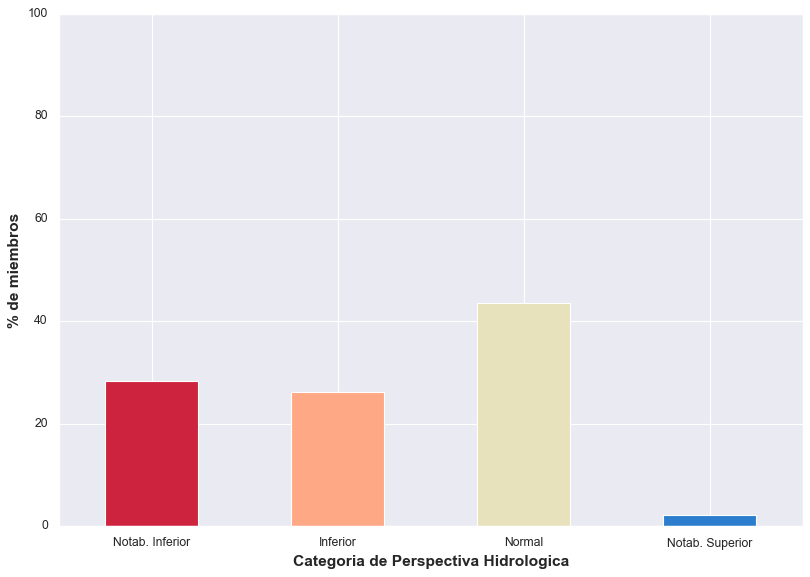

In [28]:
# OJO: SELECT FORECAST LEADTIME 
forecast_leadtime = int(args.leadtime)
# month_outlook = discharge_plot['date'] + pd.DateOffset(months=+forecast_leadtime)
month_outlook = discharge_plot['month'].iloc[-1] + forecast_leadtime

# %%
if month_outlook > 12:
    month_outlook = month_outlook - 12

print(month_outlook)

# %%
category_counts = concat_df.query('month==@month_outlook')['percentile_range'].value_counts()
category_counts = category_counts.to_frame()
category_counts = category_counts.sort_index(key=lambda x: x.map({val:idx for idx,val in enumerate(values_months)}))

# %%
category_counts_summary = concat_df.query('month==@month_outlook')['percentile_range_summary'].value_counts()
category_counts_summary = category_counts_summary.to_frame()
category_counts_summary = category_counts_summary.sort_index(key=lambda x: x.map({val:idx for idx,val in enumerate(values_months_summary)}))

# %%
category_counts['percentage_ensemble'] = round((category_counts['percentile_range']/category_counts['percentile_range'].sum())*100,1)
category_counts_summary['percentage_ensemble'] = round((category_counts_summary['percentile_range_summary']/category_counts_summary['percentile_range_summary'].sum())*100,1)

# %%
import matplotlib.colors as mcolors

color_mapping = {
    'Notab. Inferior':'#CD233F',
    'Inferior': '#FFA885',
    'Normal': '#E7E2BC',
    'Superior': '#8ECEEE',
    'Notab. Superior': '#2C7DCD'
}

column_name = category_counts.index.to_list()
colors = [mcolors.to_rgb(color_mapping.get(x,'#808080')) for x in category_counts.index]
ax3 = category_counts['percentage_ensemble'].plot(kind='bar',color=colors,figsize=(12, 8));
plt.xticks(range(len(category_counts.index)),column_name,rotation=0,horizontalalignment='center');
plt.xlabel('Categoria de Perspectiva Hidrologica',fontweight='bold',fontsize=14);
plt.ylabel('% de miembros',fontweight='bold',fontsize=14);
# set xlimits to 100%
plt.ylim(0,100)
#plt.suptitle(f'Ensemble Streamflow Prediction (ESP) en subcuenca: {codcuenca_n2}',fontweight='bold',fontsize=20);
#plt.title(f"{forecast_leadtime}-Mes de Perspectiva",fontweight='bold',fontsize=14);
# plt.savefig(f"./waterbalance/output_png/05_barplot_{forecast_leadtime}_leadtime.png", dpi=300, bbox_inches='tight')
# plt.close()
plt.show()


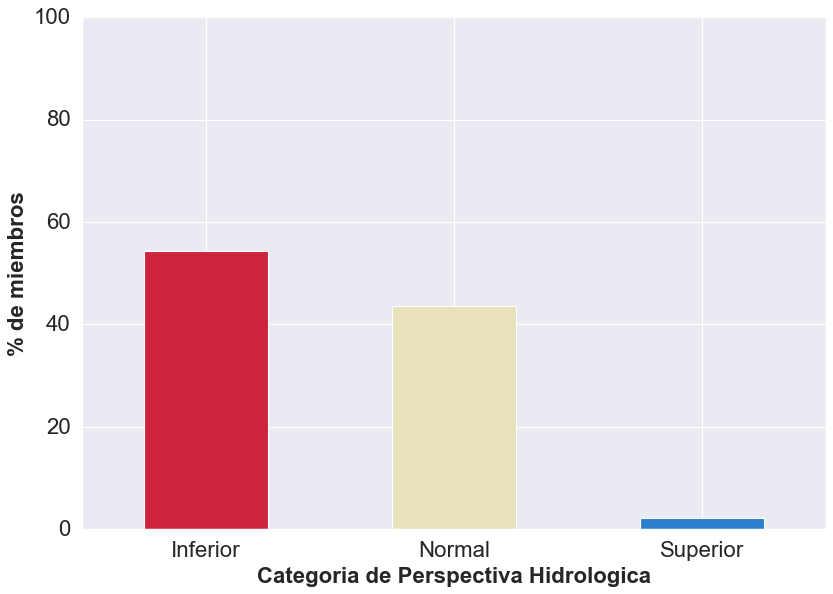

In [29]:
# %%
font_size = 18
color_mapping_summary = {
    'Inferior':'#CD233F',
    'Normal': '#E7E2BC',
    'Superior': '#2C7DCD'
}

column_name = category_counts_summary.index.to_list()
colors = [mcolors.to_rgb(color_mapping_summary.get(x,'#808080')) for x in category_counts_summary.index]
ax3 = category_counts_summary['percentage_ensemble'].plot(kind='bar',color=colors,figsize=(12, 8));
plt.xticks(range(len(category_counts_summary.index)),column_name,rotation=0,horizontalalignment='center',fontsize=20);
plt.yticks(fontsize=20)
plt.xlabel('Categoria de Perspectiva Hidrologica',fontweight='bold',fontsize=20);
plt.ylabel('% de miembros',fontweight='bold',fontsize=20);
# set xlimits to 100%
plt.ylim(0,100)
#plt.suptitle(f'Ensemble Streamflow Prediction (ESP) en subcuenca: {codcuenca_n2}',fontweight='bold',fontsize=20);
#plt.title(f"{forecast_leadtime}-Mes de Perspectiva",fontweight='bold',fontsize=14);
# plt.savefig(f"./waterbalance/output_png/06_barplot_{forecast_leadtime}_leadtime.png", dpi=300, bbox_inches='tight')
# plt.close()
plt.show()